# Aqui calcularemos o RWA do portfolio ficticio

Cálculo do RWA (Risk-Weighted Assets) para Crédito.

O RWA define quanto de capital o banco precisa manter para cada real emprestado.

- A Regra (Resolução 4.958): Ativos diferentes recebem pesos de risco (RW) diferentes.

- No Python: Criaremos um mapeamento de Produto para RW.

 Exemplo: Empréstimo sem garantia (100%), Parcelado Loja (75% ou 100% conforme o caso).

- Fórmula: $RWA = Valor\_Nocional \times RW$.

- Métrica Final: Calcule o Índice de Basileia teórico, dividindo um Patrimônio de Referência (PR) fictício pelo RWA total.

## Diferencas entre bancos S1 e S3

### Capital RWA e basileia
- **Bancos S1** utilizam com frequencia modelos internos avancados IRB (internal Ratings-based) para credito e IMA (internal models approach) para mercados

    - O banco estima suas proprias metricas de PD, LGD e EAD atraves de modelos estatisticos pesados para calcular o RWA. **Dependendo muito da qualidade dos dados.**

- **Bancos S3** utilizam a abordagem padrionizada. o banco central definie tabelas fixas de pesos de risco RW. por exemplo, uma exposicao de var3ejo padrao tem peso de 75% ou 100%

    - Impacto o calculo e mais simples de implementar, mas oferece margem para otimizacao do que os modelos internos dos S1

### Risco de taxa de juros (IRRBB)

A forma como o banco mede impact dos juros no **patrimonio** (EVE) e no **lucro** (NII) muda drasticamente

- **Bancos S1** Realizam calculos de forma granular, simulando choques em cada vertice da curva de juros e utilizando modelos comportamentais dinamicos para cada produto

- **Bancos S3** Seguem a abordagem padronizada do IRRBB (SA-IRRBB) definida na regulamentacao do BCB. Calculo: o banco agrupa os ativos e passivos em janelas de tempo (time buckets) pre-definidas. O choque de juros e aplicado sobre esses bl;ocos de forma mais simplificada

### Provisonamento (Resolução 2.682 vs. 4.966)

Estamos hoje, 07/03/2026, em um momento de transicao importante.

- Regra atual (ambos S1 e S3): ambos seguem a logica de perda incorrida (atraso gera provisao de AA a H)

- Diferenca na gestao: no S1 a gestao de risco e proativa, com modelos de provisioning rodando em tempo real. No S3  o foco e a precisao do reporte regulatorio (CADOC 3040 - responsavel pelo risco de credito)

- **Futuro (IRFS 9/ Res. 4.966)** para os bancos S1 teremos o modelo da **perda esperada**. O S3 tem cronogramas e exigencias mais simplificadas para essa transicao, mas ainda assim precisa implementar modelos de PD e LGD.

## Pesos de RW definidos pelo Bacen para o calculo do RWACAD (ativos ponderados pelo risco de credito sob abordagem padronizada)

Baseados na res. CMN 4958/2021 e Norm. BCB 200/2021

### Pesos de riscos - RWACAD

Fontes Oficiais Utilizadas:

Resolução CMN nº 4.958, de 21 de outubro de 2021: Estabelece os requisitos mínimos de Patrimônio de Referência (PR), de Nível I e de Capital Principal para as instituições do Segmento 3 (S3).

Instrução Normativa BCB nº 200, de 1º de dezembro de 2021: Estabelece os procedimentos para o cálculo da parcela dos ativos ponderados pelo risco (RWA) relativa às exposições ao risco de crédito sujeitas ao cálculo do capital pelo enfoque padronizado (RWACAD).

Resolução CMN nº 4.557, de 23 de fevereiro de 2017: Dispõe sobre a estrutura de gerenciamento de riscos e a estrutura de gerenciamento de capital (GARC).

| Tipos de exposicao/produto | Peso de risco (RW/FPR) | Requisito/ fonte oficial |
| :--- | :---: | ---: |
| `Exposicao de varejo qualificadas` | 75% | Devem atender criterios de granularidade e limite de valor por contraparte |
| `Exposicao de varejo nao qualificadas` | 100% | Exposicoes que nao atendem aos criterios de diversificacao da norma |
| `Crédito Imobiliário (Residencial)` | 35% a 100% | Varia conforme a relação Loan-to-Value (LTV) e o método de avaliação. |
| `Operações Vencidas (> 90 dias)` | 100% ou 150% | 150% se a provisão for < 20%; 100% se a provisão for ≥ 20% do valor da exposição. |
| `Títulos Públicos Federais (Brasil)` | 0% | Exposições ao Governo Federal ou Banco Central do Brasil em moeda nacional. |
| `Exposições a Instituições Financeiras` | 20% a 150% | Depende da nota de crédito (rating) ou da classificação de risco do país de origem.|


Obs: Para bancos S3 e uma obrigacao o usu da abordagem padronizada

In [8]:
# importacao de bibliotecas

import pandas as pd
import numpy as np

from collections import defaultdict

from pathlib import Path
import os

# Define a raiz do projeto (onde o script está ou um nível acima)
BASE_DIR = Path(os.getcwd()).parent / "data"
BASE_DIR

PosixPath('/home/ricardo/Documents/Projects/analise_alm/data')

In [ ]:
# leitura da base ja passado nos testes de data quality no processo data_analisys_portfolio

arq = r'base_clientes_varejo_simulada.csv'
path = os.path.join(BASE_DIR, arq)
df_base = pd.read_csv(path)

df_base.head(5)

,ID_Contrato,Produto,Valor_Nocional,Taxa_Contratada_AA,Prazo_Remanescente_Meses,Indexador,Rating_2682,Dias_Atraso
0,1001,Parcelado_Loja,23774.04,0.2138,42,POS-CDI,AA,0
1,1002,Emprestimo_Pessoal,37341.81,0.1830,21,PRE,AA,0
2,1003,Parcelado_Loja,43655.72,0.2419,35,PRE,A,0
3,1004,Parcelado_Loja,21965.94,0.2565,41,PRE,A,0
4,1005,Emprestimo_Pessoal,2661.25,0.1226,40,POS-CDI,AA,0


In [3]:
# calculando a provisao vl_provisao = nocional * % rating

# a provisao e a reserva para a perda esperada. Vamos criar um dicionario de mapeamento 
# onde cada letra corresponde a um percentual fixo definido pelo BCB.

# dict de provisao Resolução CMN nº 2.682
dict_provisao = {
    'AA': 0
    ,'A': 0.005
    ,'B': 0.01
    ,'C': 0.03
    ,'D': 0.10
    ,'E': 0.30
    ,'F': 0.50
    ,'G': 0.70
    ,'H': 1
}

df_analise = df_base.copy()


df_analise['Provisao'] = df_analise['Valor_Nocional'] * df_analise['Rating_2682'].apply(lambda x: dict_provisao[x])
df_analise.head(5)


,ID_Contrato,Produto,Valor_Nocional,Taxa_Contratada_AA,Prazo_Remanescente_Meses,Indexador,Rating_2682,Dias_Atraso,Provisao
0,1001,Parcelado_Loja,23774.04,0.2138,42,POS-CDI,AA,0,0.0000
1,1002,Emprestimo_Pessoal,37341.81,0.1830,21,PRE,AA,0,0.0000
2,1003,Parcelado_Loja,43655.72,0.2419,35,PRE,A,0,218.2786
3,1004,Parcelado_Loja,21965.94,0.2565,41,PRE,A,0,109.8297
4,1005,Emprestimo_Pessoal,2661.25,0.1226,40,POS-CDI,AA,0,0.0000


In [4]:
# atribuicao de pesos de risco, RW, - IN BCB 200/2021

df_analise['Produto'].unique()

<StringArray>
['Parcelado_Loja', 'Emprestimo_Pessoal', 'Cartao_Credito']
Length: 3, dtype: str

In [5]:
# criar dict para os produtos da base que estamos analisando

prod = defaultdict(str)

# adicionar produtos
prod['Parcelado_Loja'] = 'Varejo qualificado'
prod['Emprestimo_Pessoal'] = 'Varejo qualificado'
prod['Cartao_Credito'] = 'Varejo qualificado'

prod

defaultdict(str,
            {'Parcelado_Loja': 'Varejo qualificado',
             'Emprestimo_Pessoal': 'Varejo qualificado',
             'Cartao_Credito': 'Varejo qualificado'})

In [8]:
# dias de atraso operacao vencida > 90 dias

def cal_rw(linha):

    dias_atraso = linha['Dias_Atraso']
    provisao = linha['Provisao']
    exposicao = linha['Valor_Nocional']
    produto = linha['Produto']

    if dias_atraso > 90:

        if provisao >= (0.20 * exposicao):
            return 1
        else:
            return 1.50
        
    else:

        prodt_dict = prod[produto]
        if prodt_dict == 'Varejo qualificado':
            return 0.75
        else:
            return None
        

df_analise['rw'] = df_analise.apply(cal_rw, axis = 1)

df_analise

,ID_Contrato,Produto,Valor_Nocional,Taxa_Contratada_AA,Prazo_Remanescente_Meses,Indexador,Rating_2682,Dias_Atraso,Provisao,rw
0,1001,Parcelado_Loja,23774.04,0.2138,42,POS-CDI,AA,0,0.00000,0.75
1,1002,Emprestimo_Pessoal,37341.81,0.1830,21,PRE,AA,0,0.00000,0.75
2,1003,Parcelado_Loja,43655.72,0.2419,35,PRE,A,0,218.27860,0.75
3,1004,Parcelado_Loja,21965.94,0.2565,41,PRE,A,0,109.82970,0.75
4,1005,Emprestimo_Pessoal,2661.25,0.1226,40,POS-CDI,AA,0,0.00000,0.75
...,...,...,...,...,...,...,...,...,...,...
1995,2996,Emprestimo_Pessoal,5632.09,0.1784,14,PRE,A,0,28.16045,0.75
1996,2997,Parcelado_Loja,2908.55,0.2914,36,PRE,A,0,14.54275,0.75
1997,2998,Cartao_Credito,29260.25,0.2683,5,PRE,AA,0,0.00000,0.75
1998,2999,Parcelado_Loja,21590.51,0.2476,11,PRE,B,0,215.90510,0.75


In [9]:
# calculo do RWA

df_analise['rwa'] = df_analise['Valor_Nocional'] * df_analise['rw']

df_analise

,ID_Contrato,Produto,Valor_Nocional,Taxa_Contratada_AA,Prazo_Remanescente_Meses,Indexador,Rating_2682,Dias_Atraso,Provisao,rw,rwa
0,1001,Parcelado_Loja,23774.04,0.2138,42,POS-CDI,AA,0,0.00000,0.75,17830.5300
1,1002,Emprestimo_Pessoal,37341.81,0.1830,21,PRE,AA,0,0.00000,0.75,28006.3575
2,1003,Parcelado_Loja,43655.72,0.2419,35,PRE,A,0,218.27860,0.75,32741.7900
3,1004,Parcelado_Loja,21965.94,0.2565,41,PRE,A,0,109.82970,0.75,16474.4550
4,1005,Emprestimo_Pessoal,2661.25,0.1226,40,POS-CDI,AA,0,0.00000,0.75,1995.9375
...,...,...,...,...,...,...,...,...,...,...,...
1995,2996,Emprestimo_Pessoal,5632.09,0.1784,14,PRE,A,0,28.16045,0.75,4224.0675
1996,2997,Parcelado_Loja,2908.55,0.2914,36,PRE,A,0,14.54275,0.75,2181.4125
1997,2998,Cartao_Credito,29260.25,0.2683,5,PRE,AA,0,0.00000,0.75,21945.1875
1998,2999,Parcelado_Loja,21590.51,0.2476,11,PRE,B,0,215.90510,0.75,16192.8825


In [10]:
# capital minimo para S3

cap_min = df_analise['rwa'].sum() * 0.08
cap_min

np.float64(3090314.5074)

# Calculo do RWA para S1

Diferente do S3 onde o peso RW e fixo por tabelas no S1 o risco e uma funcao continua e nao olinear baseada em probabilidades.

A regulamentacao brasileira que rege os modelos internos de credito esta consolidada na Res. BCB 303/2023 (atualizando a 3648)

## 1. Os pilares do modelo IRB (S1)

Diferente da abordagem padronizada, voce precisa estimar internamente tres parametros fundamentais para cada contrato ou segmento

- **PD (probabilidade de default)**: prob de um cliente dar default em 1 ano;

- **LGD (Loss Given Default)**: Percentual da exposicao que o banco efetivamente perde apos o calote;

- **EAD (Exposure at Default)**: o valor da exposicao no momento do default -  o valor que se espera que o cliente esteja devendo no exato momento em que ele "quebrar".

## 2. A formula de ponderacao de risco (Varejo)

Para a esxposicao de varejo (como cartoes e emprestimos), o banco cenral define a correlacao, R, e o requisito de capital, K, atraves da formula baseada na distribuicao normal.

- Calculo da correlacao R

$$R = 0,03 \cdot \left( \frac{1 - e^{-35 \cdot PD}}{1 - e^{-35}} \right) + 0,16 \cdot \left[ 1 - \left( \frac{1 - e^{-35 \cdot PD}}{1 - e^{-35}} \right) \right]$$

- calculo do capital K

$$K = \left[ LGD \cdot N \left( \frac{G(PD)}{\sqrt{1 - R}} + \sqrt{\frac{R}{1 - R}} \cdot G(0,999) \right) - (PD \cdot LGD) \right]$$

onde: 
    - N(x) e a funcao de distribuicao normal acumulada
    - G(z) e a inversa da funcao de distribuicao normal acumulada
    - RWA final: RWA = K * 12.5 * EAD

## 3. Regra do output floor (S1 vs S3)

Uma regra crucial para bancos S1 e o limite de otimizacao de capital. O comite de basileia III  esabelece que o RWA calculado por modelos internos nao pode ser inferior a um percentual do valor que seria obtido pelo modelo padronizado

- **Piso atual**: O RWA via IRB deve ser no minimo 72.5% do RWA que o banco calcularia se usasse a abordagem padronizada (S3)

- **Objetivo**: Evitar que bancos grandes reduzam excessivamente o capital regulatorio atraves de modelos internos agressivos

### Para que possamos calcular o RWA para um banco S1 precisamos de informacoes extras

 - PD
 - LGD
 - EAD

In [9]:
# leitura da base ja passado nos testes de data quality no processo data_analisys_portfolio

arq2 = r'base_clientes_varejo_simulada_pds.csv'
path2 = os.path.join(BASE_DIR, arq2)

df_base_pds = pd.read_csv(path2)
df_base_pds.head(5)

,ID_Contrato,Produto,Valor_Nocional,Taxa_Contratada_AA,Prazo_Remanescente_Meses,Indexador,Rating_2682,Dias_Atraso,PD,LGD,EAD
0,1001,Parcelado_Loja,23774.04,0.2138,42,POS-CDI,AA,0,0.001,0.65,23774.04
1,1002,Emprestimo_Pessoal,37341.81,0.1830,21,PRE,AA,0,0.001,0.75,37341.81
2,1003,Parcelado_Loja,43655.72,0.2419,35,PRE,A,0,0.005,0.65,43655.72
3,1004,Parcelado_Loja,21965.94,0.2565,41,PRE,A,0,0.005,0.65,21965.94
4,1005,Emprestimo_Pessoal,2661.25,0.1226,40,POS-CDI,AA,0,0.001,0.75,2661.25


In [20]:
# calculo da correlacao R
from scipy.stats import norm
import math

df_analise_pd = df_base_pds.copy()
def calc_r(linha):
    pd = linha['PD']

    # 1. Cálculo da parte comum (a fração com e)
    # math.exp(x) é o mesmo que e^x
    numerador_e = 1 - math.exp(pd)
    denominador_e = 1 - math.exp(-35)
    fracao_e = numerador_e / denominador_e
    
    # 2. Cálculo de R
    r = 0.03 * fracao_e + 0.16 * (1 - fracao_e)
    return r

df_analise_pd['r'] = df_analise_pd.apply(calc_r, axis = 1)

df_analise_pd

,ID_Contrato,Produto,Valor_Nocional,Taxa_Contratada_AA,Prazo_Remanescente_Meses,Indexador,Rating_2682,Dias_Atraso,PD,LGD,EAD,r
0,1001,Parcelado_Loja,23774.04,0.2138,42,POS-CDI,AA,0,0.001,0.65,23774.04,0.160130
1,1002,Emprestimo_Pessoal,37341.81,0.1830,21,PRE,AA,0,0.001,0.75,37341.81,0.160130
2,1003,Parcelado_Loja,43655.72,0.2419,35,PRE,A,0,0.005,0.65,43655.72,0.160652
3,1004,Parcelado_Loja,21965.94,0.2565,41,PRE,A,0,0.005,0.65,21965.94,0.160652
4,1005,Emprestimo_Pessoal,2661.25,0.1226,40,POS-CDI,AA,0,0.001,0.75,2661.25,0.160130
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2996,Emprestimo_Pessoal,5632.09,0.1784,14,PRE,A,0,0.005,0.75,5632.09,0.160652
1996,2997,Parcelado_Loja,2908.55,0.2914,36,PRE,A,0,0.005,0.65,2908.55,0.160652
1997,2998,Cartao_Credito,29260.25,0.2683,5,PRE,AA,0,0.001,0.85,33200.14,0.160130
1998,2999,Parcelado_Loja,21590.51,0.2476,11,PRE,B,0,0.010,0.65,21590.51,0.161307


In [21]:
# calculo do capital K
from scipy.stats import norm
import math

def calc_k(linha):

    pd = linha['PD']
    lgd = linha['LGD']
    r = linha['r']

    # 1. Funções estatísticas (Normais)
    # G(PD) é a inversa da normal acumulada: norm.ppf
    # N(...) é a normal acumulada: norm.cdf
    G_PD = norm.ppf(pd)
    G_0999 = norm.ppf(0.999)
    
    # 2. Cálculo de K
    # Dividimos em partes para facilitar a leitura
    termo_1 = G_PD / math.sqrt(1 - r)
    termo_2 = math.sqrt(r / (1 - r)) * G_0999
    
    N_total = norm.cdf(termo_1 + termo_2)
    
    k = (lgd * N_total) - (pd * lgd)
    return k

df_analise_pd['k'] = df_analise_pd.apply(calc_k, axis = 1)

df_analise_pd

,ID_Contrato,Produto,Valor_Nocional,Taxa_Contratada_AA,Prazo_Remanescente_Meses,Indexador,Rating_2682,Dias_Atraso,PD,LGD,EAD,r,k
0,1001,Parcelado_Loja,23774.04,0.2138,42,POS-CDI,AA,0,0.001,0.65,23774.04,0.160130,0.013361
1,1002,Emprestimo_Pessoal,37341.81,0.1830,21,PRE,AA,0,0.001,0.75,37341.81,0.160130,0.015416
2,1003,Parcelado_Loja,43655.72,0.2419,35,PRE,A,0,0.005,0.65,43655.72,0.160652,0.043680
3,1004,Parcelado_Loja,21965.94,0.2565,41,PRE,A,0,0.005,0.65,21965.94,0.160652,0.043680
4,1005,Emprestimo_Pessoal,2661.25,0.1226,40,POS-CDI,AA,0,0.001,0.75,2661.25,0.160130,0.015416
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2996,Emprestimo_Pessoal,5632.09,0.1784,14,PRE,A,0,0.005,0.75,5632.09,0.160652,0.050401
1996,2997,Parcelado_Loja,2908.55,0.2914,36,PRE,A,0,0.005,0.65,2908.55,0.160652,0.043680
1997,2998,Cartao_Credito,29260.25,0.2683,5,PRE,AA,0,0.001,0.85,33200.14,0.160130,0.017472
1998,2999,Parcelado_Loja,21590.51,0.2476,11,PRE,B,0,0.010,0.65,21590.51,0.161307,0.070207


### Calculo RWA

Para calcular o capital final de um banco S1 após a obtenção do RWA, você deve aplicar os percentuais de exigência mínima de capital e os Adicionais de Capital Principal (ACP) exigidos pelo Banco Central do Brasil, seguindo rigorosamente os padrões de Basileia III.

Diferente do banco S3, o banco S1 possui camadas extras de proteção devido à sua importância sistêmica.

#### 1. Os Requisitos Mínimos de Capital
O capital que o banco precisa manter é dividido em três níveis, todos calculados como uma porcentagem do RWA total:

Capital Principal (CET1): Mínimo de 4,5% do RWA.

Capital de Nível 1: Mínimo de 6,0% do RWA.

Patrimônio de Referência (PR - Total): Mínimo de 8,0% do RWA.

**BIZU:**

**O Patrimônio de Referência (PR)** - O "Headline Number"
Este é o valor que define o Índice de Basileia. Quando você quer saber "quanto de capital essa carteira de R$ 50 milhões consome", você usa o PR.

Mínimo Regulatório: 8% do RWA.

Com Adicionais (S1): Para um banco S1, você deve somar os "buffers" (ACPs). Na prática, o seu "piso" real de PR será de aproximadamente 11,5% (8% + 2,5% de Conservação + 1,0% Sistêmico).

CET1 e Nível 1 - A "Qualidade" do Capital
Eles não são valores diferentes de capital, mas sim restrições de qualidade sobre o PR que você já calculou.

**CET1 (Capital Principal - 4,5%)**: É o capital mais puro (ações e lucros retidos). É o mais difícil de conseguir. Se o banco tem muito capital total (PR), mas pouco CET1, ele está em risco regulatório.

**Nível 1 (6,0%)**: Inclui o CET1 mais instrumentos híbridos de capital e dívida.

#### 2. Os Adicionais de Capital Principal (ACP) para S1
Para chegar ao valor real de capital que o banco deve carregar, você deve somar ao mínimo de 8% os "colchões" de liquidez (buffers) que são obrigatórios para o segmento S1:

ACP Conservação: Uma parcela fixa de 2,5% do RWA para todos os bancos.

ACP Sistêmico: Exclusivo para bancos de grande porte (S1). O percentual varia conforme a relevância da instituição, mas geralmente adiciona pelo menos 1% ou mais ao requisito.

ACP Contracíclico: Pode variar de 0% a 2,5% dependendo do ciclo econômico (atualmente em 0% no Brasil).

Exemplo de Cálculo Final para S1: 

$$\text{Capital Mínimo Total} = RWA \times (8,0\% \text{ (Mínimo)} + 2,5\% \text{ (Conservação)} + 1,0\% \text{ (Sistêmico)}) = RWA \times 11,5\%$$

In [22]:
# calculo do RWA

df_analise_pd["RWA"] = df_analise_pd["k"] * 12.5 * df_analise_pd["EAD"]
df_analise_pd

,ID_Contrato,Produto,Valor_Nocional,Taxa_Contratada_AA,Prazo_Remanescente_Meses,Indexador,Rating_2682,Dias_Atraso,PD,LGD,EAD,r,k,RWA
0,1001,Parcelado_Loja,23774.04,0.2138,42,POS-CDI,AA,0,0.001,0.65,23774.04,0.160130,0.013361,3970.509798
1,1002,Emprestimo_Pessoal,37341.81,0.1830,21,PRE,AA,0,0.001,0.75,37341.81,0.160130,0.015416,7195.923781
2,1003,Parcelado_Loja,43655.72,0.2419,35,PRE,A,0,0.005,0.65,43655.72,0.160652,0.043680,23836.279354
3,1004,Parcelado_Loja,21965.94,0.2565,41,PRE,A,0,0.005,0.65,21965.94,0.160652,0.043680,11993.532167
4,1005,Emprestimo_Pessoal,2661.25,0.1226,40,POS-CDI,AA,0,0.001,0.75,2661.25,0.160130,0.015416,512.834064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2996,Emprestimo_Pessoal,5632.09,0.1784,14,PRE,A,0,0.005,0.75,5632.09,0.160652,0.050401,3548.254843
1996,2997,Parcelado_Loja,2908.55,0.2914,36,PRE,A,0,0.005,0.65,2908.55,0.160652,0.043680,1588.085371
1997,2998,Cartao_Credito,29260.25,0.2683,5,PRE,AA,0,0.001,0.85,33200.14,0.160130,0.017472,7250.847434
1998,2999,Parcelado_Loja,21590.51,0.2476,11,PRE,B,0,0.010,0.65,21590.51,0.161307,0.070207,18947.471315


In [23]:
# capital minimo para S1

cap_min_pd_cet1 = df_analise['rwa'].sum() * 0.045
print(rf'Capital principal CET1 - {cap_min_pd_cet1}')

cap_min_pd_lvl1 = df_analise['rwa'].sum() * 0.06
print(rf'Capital de Nivel 1 - {cap_min_pd_lvl1}')

cap_min_pd_prtot = df_analise['rwa'].sum() * 0.08
print(rf'Patrimonio de referencia - {cap_min_pd_prtot}')

Capital principal CET1 - 1738301.9104125
Capital de Nivel 1 - 2317735.88055
Patrimonio de referencia - 3090314.5074


In [ ]:
# capital de referencia

capital_pd = df_analise['rwa'].sum() * 0.115

capital_pd

np.float64(4442327.1043875)

In [29]:
# economia de capital

economia = cap_min - capital_pd
economia

np.float64(-1352012.5969875003)

In [36]:
# RWA CIRB

rwa = max(capital_pd, cap_min * 0.725)
rwa

np.float64(4442327.1043875)

### Analise da comparacao

Aqui vemos que perfeitamente possível que o capital exigido pelo modelo IRB (S1) seja maior que o do modelo Padronizado (S3). Embora o objetivo dos modelos internos seja a otimização, a "sensibilidade ao risco" funciona para os dois lados: ela premia o baixo risco, mas penaliza severamente o risco alto.

#### 1. Carteiras de Alto Risco (Sensibilidade da PD e LGD)

No modelo S3 (Padronizado), um cliente de varejo tem um peso de risco (RW) fixo de 75%, independentemente de ele ser um cliente "bom" ou "médio".No modelo IRB (S1), se o seu modelo estatístico identificar que um segmento de clientes tem uma PD (Probabilidade de Default) muito alta ou uma LGD (Perda dado o Default) elevada, a fórmula da Resolução BCB nº 303/2023 pode gerar um peso de risco superior a 100% ou até 150%.Exemplo: Se a PD e a LGD forem altas o suficiente, o capital $K$ calculado pode resultar em um RW de 120%. Nesse caso, o banco S1 pagaria muito mais capital por esse cliente do que o banco S3 (que pagaria apenas sobre 75%).

#### 2. Adicionais de Capital (ACP) mais Pesados

A régua de capital para um banco S1 é mais alta devido à sua importância para o sistema financeiro:Banco S3: Paga o mínimo de 8% + ACP Conservação (2,5%) = 10,5%.Banco S1: Paga os mesmos 10,5% + o ACP Sistêmico (que pode ser de 1% a 2%) = 11,5% a 12,5%.Se a sua modelagem interna (IRB) não conseguir reduzir o RWA o suficiente para compensar esse "pedágio" extra de 1% ou 2% do ACP Sistêmico, o capital total em Reais será maior no S1.

#### 3. O Período de Estresse nos Modelos (Downtime LGD)

A regulação para bancos S1 (Resolução 303) exige que as estimativas de LGD considerem períodos de estresse econômico (Downtime LGD).Se o histórico do banco mostra que, em crises passadas, as recuperações de crédito foram péssimas, o modelo IRB é obrigado a usar essa perda alta no cálculo atual.O modelo Padronizado (S3) ignora esse histórico específico do banco e usa a média genérica do mercado, o que pode acabar sendo "mais barato" em termos de capital durante períodos de deterioração.

In [28]:
# outputfloor

out_floor = (capital_pd / cap_min - 1) * 100

out_floor

np.float64(43.75)

### O BREAKEVEN

Vamos agora realizar a analise de como fariamos para ter um breakeven etre uma analise IRB e uma padronizada.

O objetivo e descobrir qual e a PD limite que um cliente pode ter para que ainda valha a pena usar o modelo interno.

#### 1. definindo funcao de custo

- **Custo S3 - padronizada** EAD * 0.75 * 0.105
    - Obs: 75% e o peso de varejo e de 10.5% e o minmo de 8% + ACP conservacao de 2.5%

- **Custo S1 - IRB** EAD * K(PD, LGD) * 12.5 * 11.5%
    - Obs: K e a funcao de capital da res. 303. 11.5% inclui o ACP sistemico de 1%

#### 2. Raciocinio para o calculo

O breakeven ocorre quando:

$$0.07875 * EAD = EAD * K(PD, LGD) * 12.5 * 0.115$$

Faremos isso fixando a LDG em 75% e variando a PD ate que os dois lados da eq se igualem

$$ K(PD, LGD) = 5.478\% $$

In [35]:
# Analise do breakeven

df_breakeven = pd.merge(left=df_analise[['ID_Contrato', 'Valor_Nocional', 'rw', 'rwa']]
                            ,right=df_analise_pd[['ID_Contrato', 'Valor_Nocional', 'PD', 'LGD', 'EAD', 'r', 'k', 'RWA']]
                            ,left_on= ['ID_Contrato', 'Valor_Nocional']
                            ,right_on= ['ID_Contrato', 'Valor_Nocional']
                            ,how= 'left')

df_breakeven

,ID_Contrato,Valor_Nocional,rw,rwa,PD,LGD,EAD,r,k,RWA
0,1001,23774.04,0.75,17830.5300,0.001,0.65,23774.04,0.160130,0.013361,3970.509798
1,1002,37341.81,0.75,28006.3575,0.001,0.75,37341.81,0.160130,0.015416,7195.923781
2,1003,43655.72,0.75,32741.7900,0.005,0.65,43655.72,0.160652,0.043680,23836.279354
3,1004,21965.94,0.75,16474.4550,0.005,0.65,21965.94,0.160652,0.043680,11993.532167
4,1005,2661.25,0.75,1995.9375,0.001,0.75,2661.25,0.160130,0.015416,512.834064
...,...,...,...,...,...,...,...,...,...,...
1995,2996,5632.09,0.75,4224.0675,0.005,0.75,5632.09,0.160652,0.050401,3548.254843
1996,2997,2908.55,0.75,2181.4125,0.005,0.65,2908.55,0.160652,0.043680,1588.085371
1997,2998,29260.25,0.75,21945.1875,0.001,0.85,33200.14,0.160130,0.017472,7250.847434
1998,2999,21590.51,0.75,16192.8825,0.010,0.65,21590.51,0.161307,0.070207,18947.471315


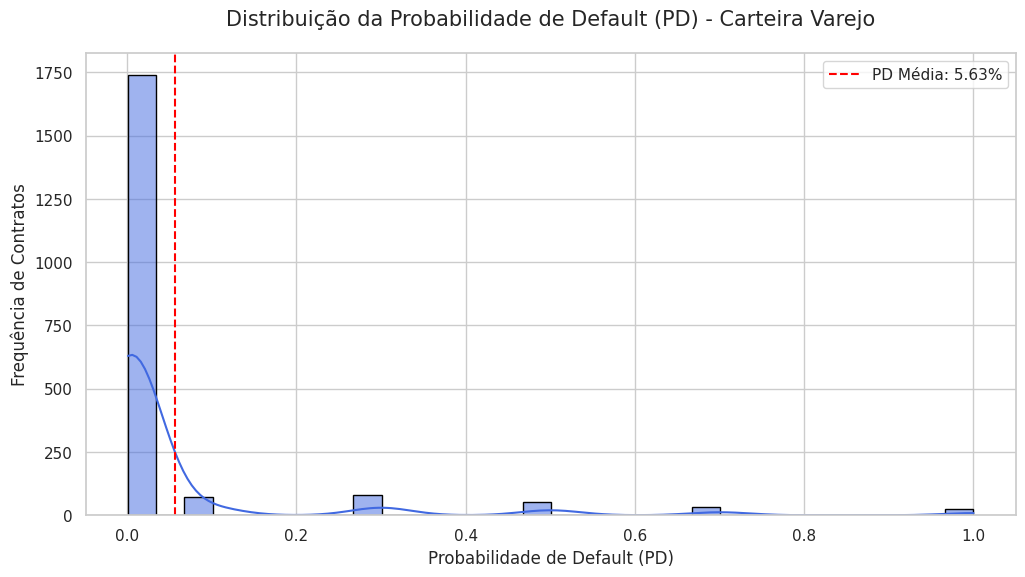

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual do gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Criando o histograma com a linha de densidade
ax = sns.histplot(df_breakeven['PD'], kde=True, bins=30, color='royalblue', edgecolor='black')

# Adicionando títulos e rótulos
plt.title('Distribuição da Probabilidade de Default (PD) - Carteira Varejo', fontsize=15, pad=20)
plt.xlabel('Probabilidade de Default (PD)', fontsize=12)
plt.ylabel('Frequência de Contratos', fontsize=12)

# Adicionando uma linha vertical para a PD Média (Insight de ALM)
pd_media = df_breakeven['PD'].mean()
plt.axvline(pd_media, color='red', linestyle='--', label=f'PD Média: {pd_media:.2%}')
plt.legend()

plt.show()